# Signal-to-noise (SNR) analysis and how fast we can reach SNR of 3

SNR for coincidence histogram can be expressed as $\mathrm{SNR} = \frac{S}{\sqrt{B}}$, where $S$ is the height of the signal, B is the background level corresponding to random coincidences. Random coincidences are the Poissonian process, so the standard deviation (background oscillations) is $\sqrt{B}$.

Instead of the signal height $S$, we prefer to work with contrast $C = \frac{S}{B}$ as it directly corresponds to the $g^{(2)}$ function, which goes from 1 to 2 for thermal light (Hanbury Brown-Twiss effect).

Therefore, SNR can be written as:

$\mathrm{SNR} = C\sqrt{B}$.

## Poissonian process

The photons we get from our sources (stars, Ne or Ar lamps, LEDs) arrive independently to our camera at a constant average rate. For estimating the background level $B$, we want to know how many photon detections will occur in a time interval $\Delta t$. The probability of seeing $k$ photons in a time interval $\Delta t$ when the expected number of events in the same time interval is $\lambda$:

$p(k, \lambda) = \frac{\lambda^{k}\exp(-\lambda)}{k!}$,

where for the photon rate $R$, we expect to see $R\Delta t$ events in a $\Delta t$ time interval. Therefore, the probability of seeing at least one photon in that interval is:

$P(k\ge1) = 1 - P(k=0) = 1 - \exp(R\Delta t) = $ |Taylor expansion| $ = 1 - (1 - x + \frac{x^2}{2!} - \frac{x^3}{3!} + ...) = x + ... $.

We typically work with $R \sim 100$ kHz and $\Delta t \sim 18 $ ps is the time resolution of our camera which we select as our time interval as it corresponds to the bin width in the histogram of coincidences. The product therefore is $R\Delta t \sim 10^{-7}$, so the Taylor expansion can be reduced down to $x$ as further elements will be very small.

Therefore, to see at least one photon from a beam of light with a photon rate of $R$ in a time interval of $\Delta t$ is:

$P = R\Delta t$.

We have two beams, therefore for each of them we have $R_{1}\Delta t$, $R_{2}\Delta t$.

## Coincidences

Coincidences occur when there are two beams of light and both have at least one photon in the same time interval. The probability of such an event is $P = R_{1}\Delta t R_{2}\Delta t$. That is just in a single time bin $\Delta t$, but we collect for much longer than that $T \gg \Delta t$, and the total number of time bins is $\frac{T}{\Delta t}$.

The number of random coincidences for the whole time of collecting data $T$ therefore is:

$ B = R_{1}R_{2}\Delta t^{2} \cdot \frac{T}{\Delta t} = R_{1}R_{2}T\Delta t$.

## Expected SNR

The expected SNR based on the amount of time we collected for and the photon rates of the two beams of light we are woring with is:

$\mathrm{SNR} = C\sqrt{B} = C\sqrt{R_{1}R_{2}T\Delta t}$.

The total collection time $T$ consists of the number of acquisition cycles $N_{\mathrm{c}}$ (typically 1000), the length of each cycle $l$ (typically 250 us or 4 ms), and the number of data files $N_{\mathrm{f}}$:

$T = N_{\mathrm{f}}N_{\mathrm{c}}l$. 

The expected SNR for such data set therefore is:

$\mathrm{SNR} = C\sqrt{B} = C\sqrt{R_{1}R_{2}\Delta tN_{\mathrm{f}}N_{\mathrm{c}}l}$,

where we measure $R_1$ and $R_2$ and we manually set the rest of the parameters.

## How fast to SNR of 3

SNR of 3 is the minimal one for which we can confidently say that what we see is an HBT peak and not some random oscillation of the background. The number of data files we need to accumulate to see SNR of at least 3 is:

$N_{\mathrm{f}} = \frac{9}{C^2R_1R_2\Delta tN_{\mathrm{c}}l}$

In [17]:
import numpy as np


def expected_SNR(
    C, r1, r2, multiplier, number_of_files, number_of_acq, acq_length
):
    """Calculate the expected SNR based on the parameters of the data set.

    Parameters
    ----------
    C : float
        Expected contrast of the HBT peak. For single polarized Ne line,
        we expected to see 50% contrast.
    r1 : float
        Photon rate in the first pixel.
    r2 : float
        Photon rate in the second pixel.
    multiplier : int
        Histogram bin width multiplier used for coarser binning.
    number_of_files : int
        Number of data files collected.
    number_of_acq : int
        Number of acquisition cycles per data file, typically 1000.
    acq_length : float
        Length of each acquisition cycle, typically 250 us or 4 ms.

    Returns
    -------
    SNR : float
        Expected SNR.
    """
    return C * np.sqrt(
        r1
        * r2
        * 2500e-12
        / 140
        * multiplier
        * number_of_files
        * number_of_acq
        * acq_length
    )


expected_SNR(0.5, 74e3, 100e3, 4, 400, 1000, 4e-3)

np.float64(14.540583599999398)

In [15]:
def time_to_SNR_of_3(C, r1, r2, multiplier, number_of_acq, acq_length):
    """Calculate the number of files to see SNR of 3.

    Parameters
    ----------
    C : float
        Expected contrast of the HBT peak. For single polarized Ne line,
        we expected to see 50% contrast.
    r1 : float
        Photon rate in the first pixel.
    r2 : float
        Photon rate in the second pixel.
    multiplier : int
        Histogram bin width multiplier used for coarser binning.
    number_of_files : int
        Number of data files collected.
    number_of_acq : int
        Number of acquisition cycles per data file, typically 1000.
    acq_length : float
        Length of each acquisition cycle, typically 250 us or 4 ms.

    Returns
    -------
    number_of_files : float
        Number of data files to collect.
    """
    return 9 / (C**2 * r1 * r2 * 2500e-12 / 140 * multiplier) / number_of_acq / acq_length

time_to_SNR_of_3(0.5, 74e3, 100e3, 3, 1000, 4e-3)

22.7027027027027

# Measured SNR

Ne 703, polarized. 400 data files collected, 4 ms acquisition windows, 1000 windows per cycle.


> > > Collecting data for sensor population plot,Working in D:\LinoSPAD2\Data\NL11\2025.10.08 < < <




> > > Plotting < < <

> > > The plot is saved as '0000246030-0000246429.png' in D:\LinoSPAD2\Data\NL11\2025.10.08\results\sensor_population < < <


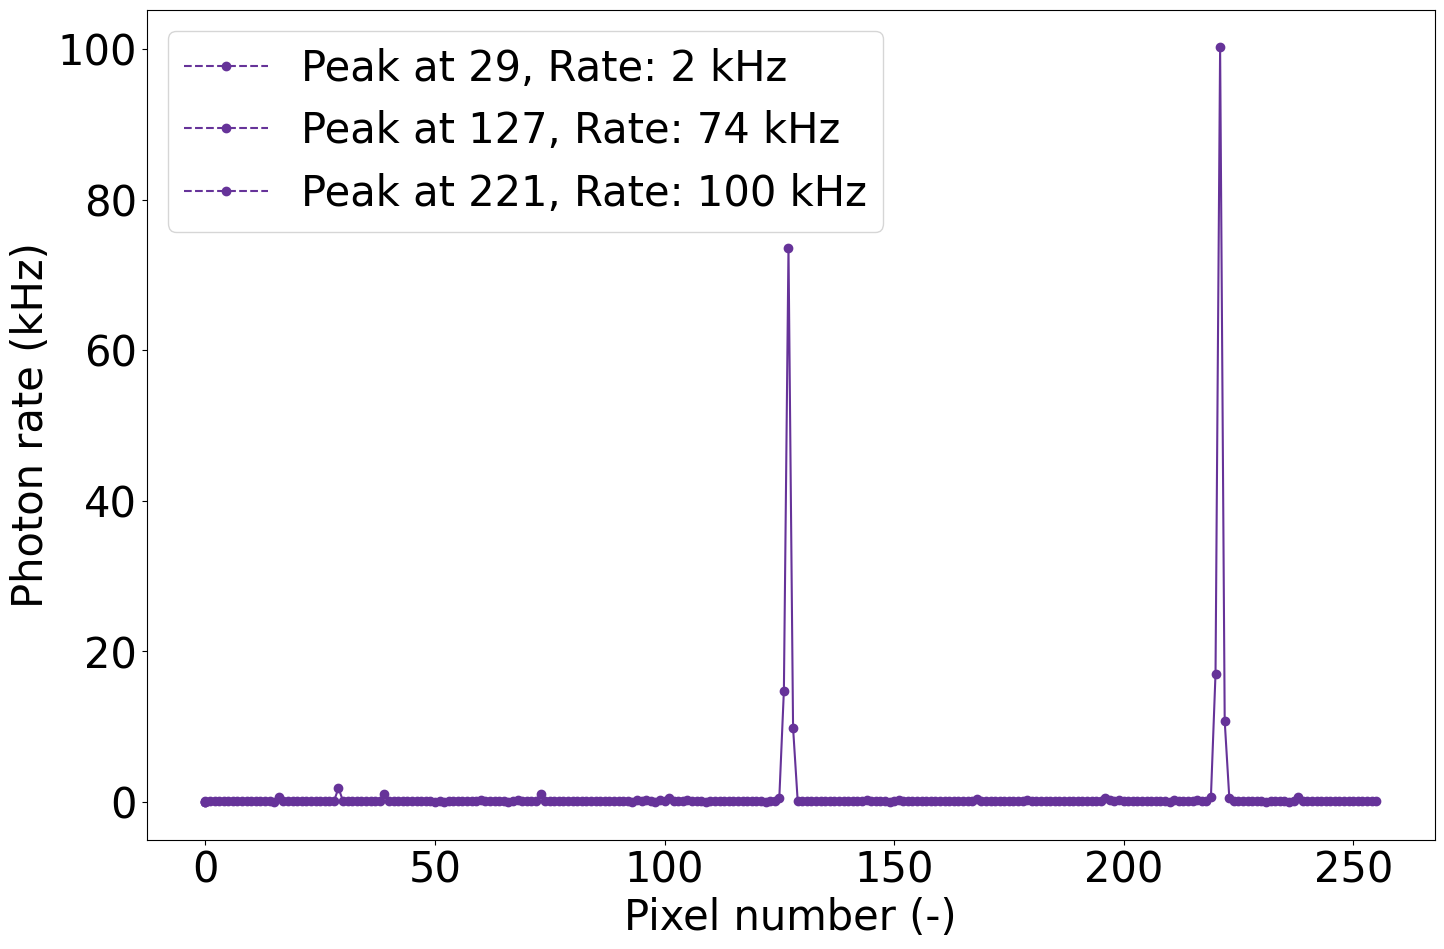

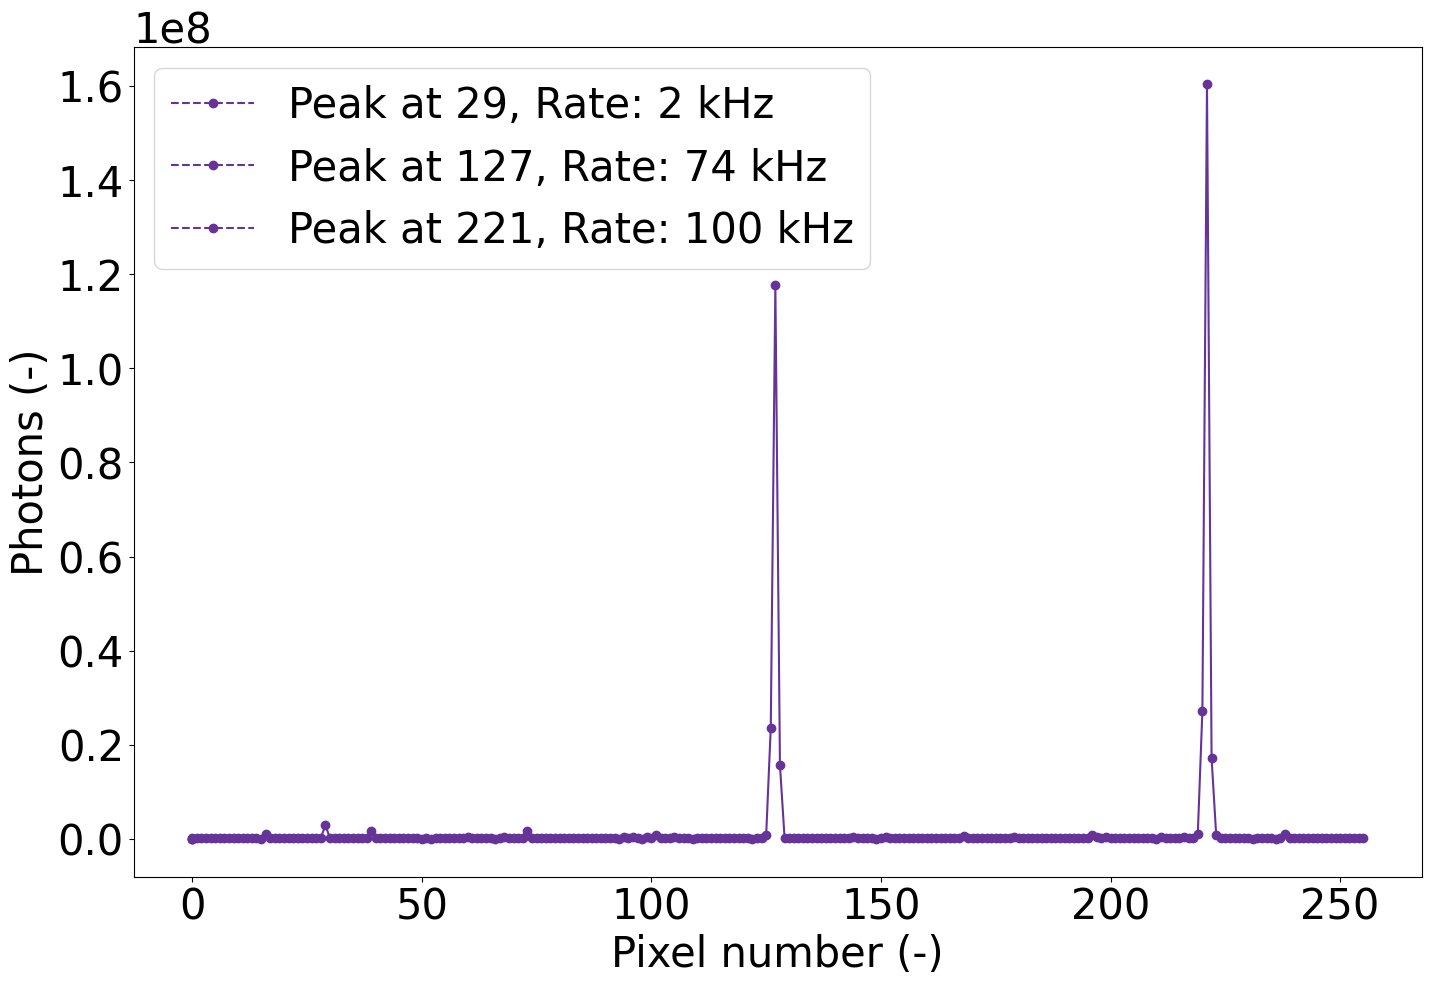

In [11]:
from daplis.functions import sensor_plot, delta_t, fits

path = r"D:\LinoSPAD2\Data\NL11\2025.10.08"

sensor_plot.plot_sensor_population(
    path,
    daughterboard_number="NL11",
    motherboard_number="#33",
    firmware_version="2212b",
    timestamps=800,
)

In [13]:
delta_t.calculate_and_save_timestamp_differences(
    path,
    rewrite=True,
    pixels=[127, 221],
    daughterboard_number="NL11",
    motherboard_number="#33",
    firmware_version="2212b",
    timestamps=800,
    include_offset=True,
)


> > > Collecting data for delta t plot for the requested pixels and saving it to .feather in a cycle < < <




> > > Timestamp differences are saved as0000246030-0000246429.feather in D:\LinoSPAD2\Data\NL11\2025.10.08\delta_ts_data < < <


[[Model]]
    (Model(gaussian) + Model(linear))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 31
    # data points      = 83
    # variables        = 5
    chi-square         = 292502.889
    reduced chi-square = 3750.03704
    Akaike info crit   = 687.893305
    Bayesian info crit = 699.987508
    R-squared          = 0.89189997
[[Variables]]
    amplitude:  271523.406 +/- 13359.9629 (4.92%) (init = 470571.4)
    center:    -5323.92297 +/- 6.04428726 (0.11%) (init = -5321.395)
    sigma:      112.332965 +/- 6.15790256 (5.48%) (init = 142.8571)
    fwhm:       264.523912 +/- 14.5007521 (5.48%) == '2.3548200*sigma'
    height:     964.295494 +/- 45.2091375 (4.69%) == '0.3989423*amplitude/max(1e-15, sigma)'
    slope:      0.00320124 +/- 0.00393521 (122.93%) (init = -0.001306494)
    intercept:  2006.92371 +/- 20.9264287 (1.04%) (init = 2030.023)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = +0.9409
    C(amplitude, sigma)

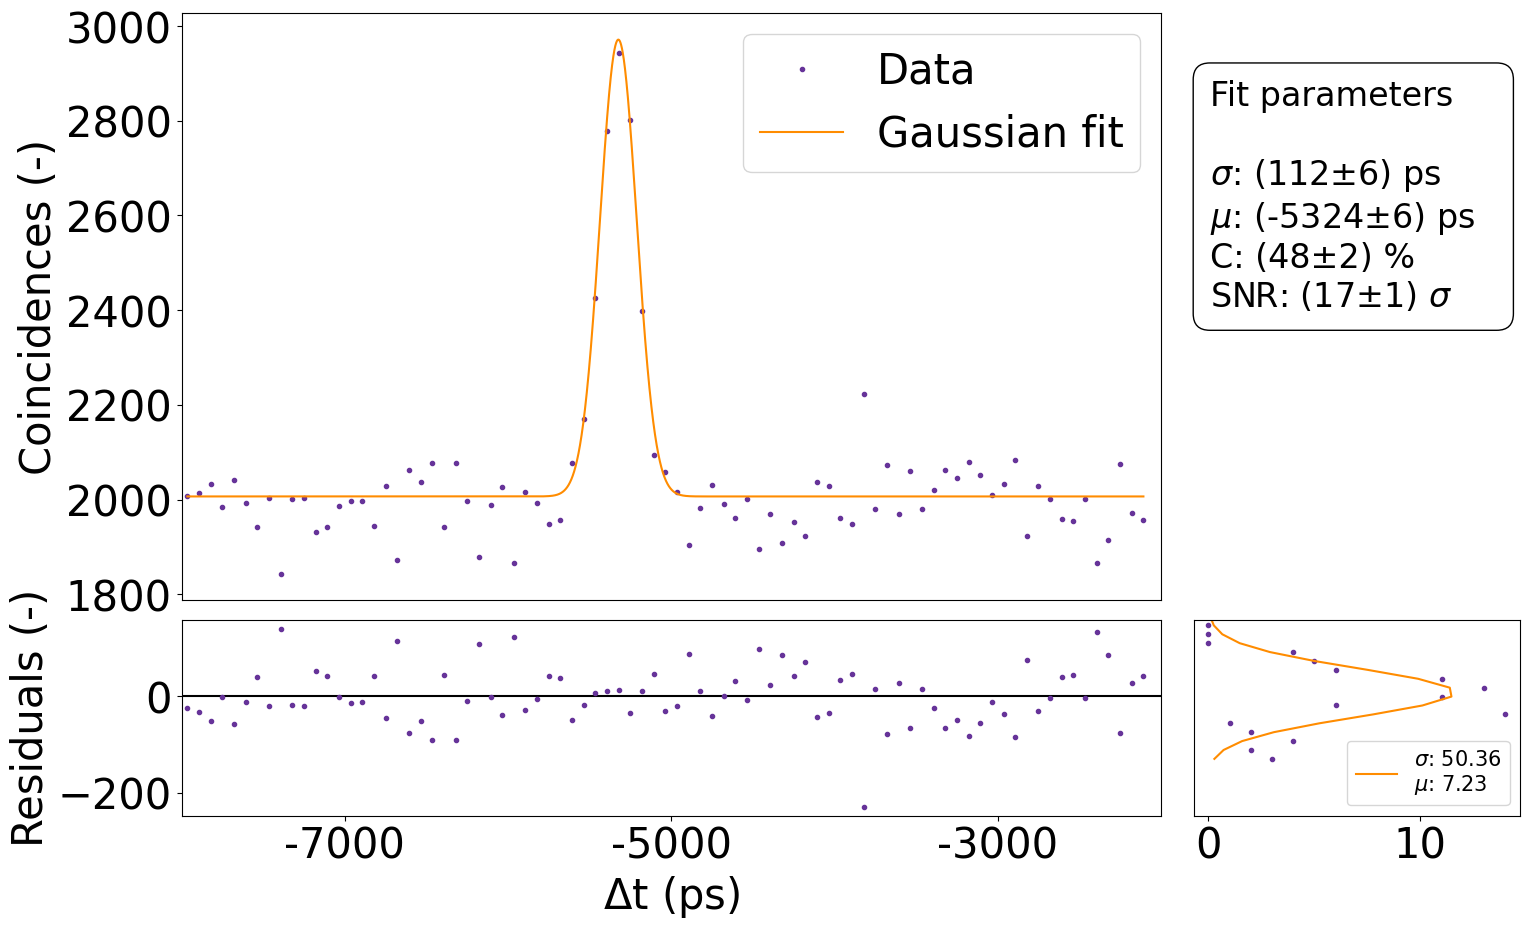

In [19]:
fits.fit_with_gaussian_fancy(
    path, pixels=[127, 221], range_left=-8e3, range_right=-2e3, multiplier=4
)

# 23 files - checking if SNR is around 3


> > > Collecting data for sensor population plot,Working in D:\LinoSPAD2\Data\NL11\2025.10.08\23files < < <




> > > Plotting < < <

> > > The plot is saved as '0000246030-0000246052.png' in D:\LinoSPAD2\Data\NL11\2025.10.08\23files\results\sensor_population < < <


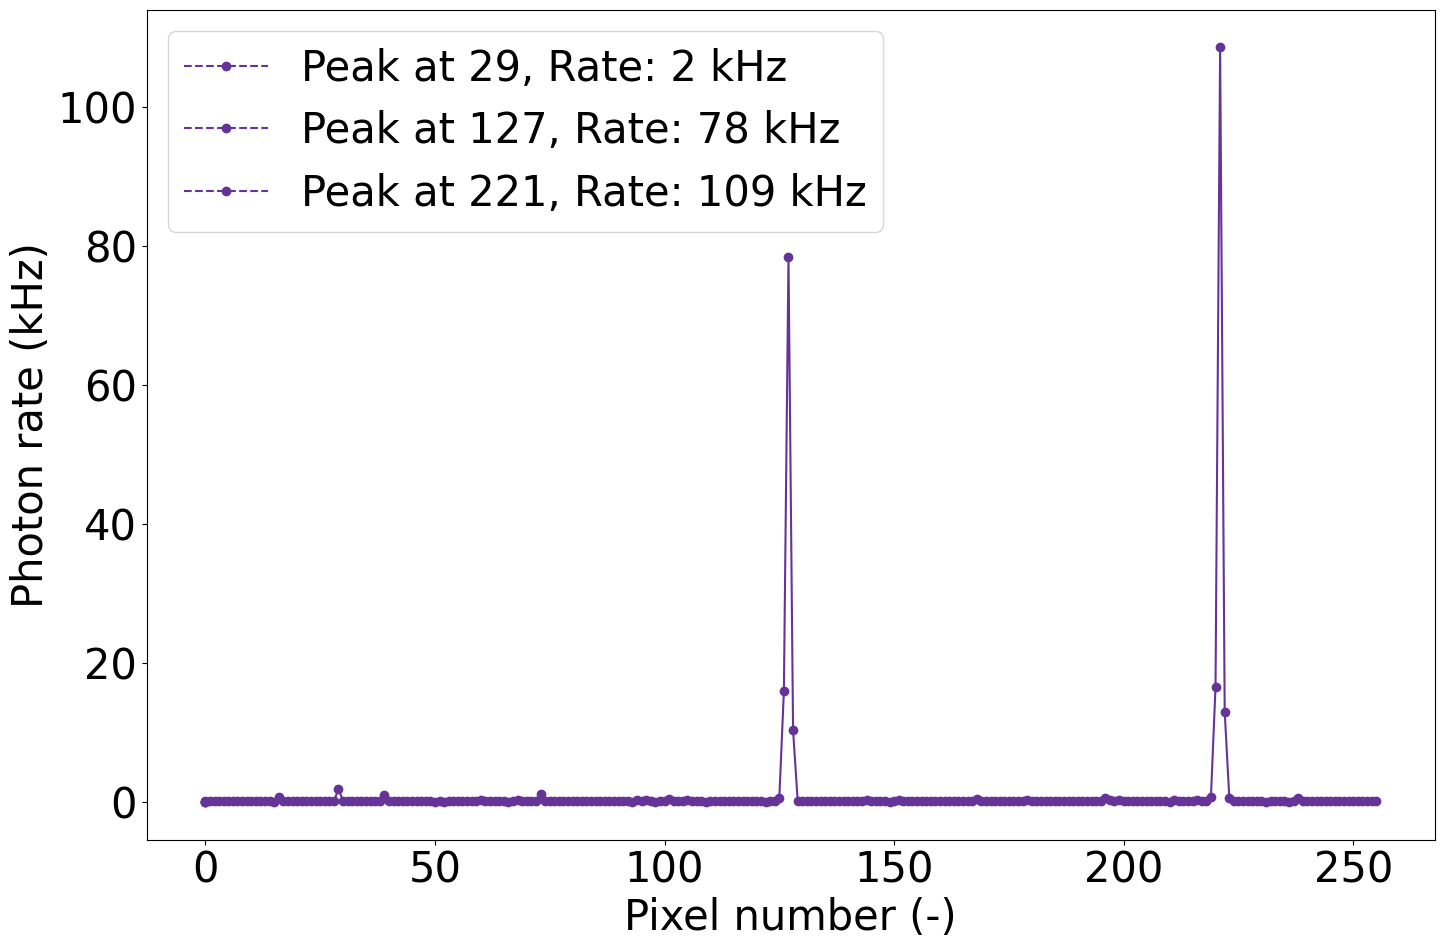

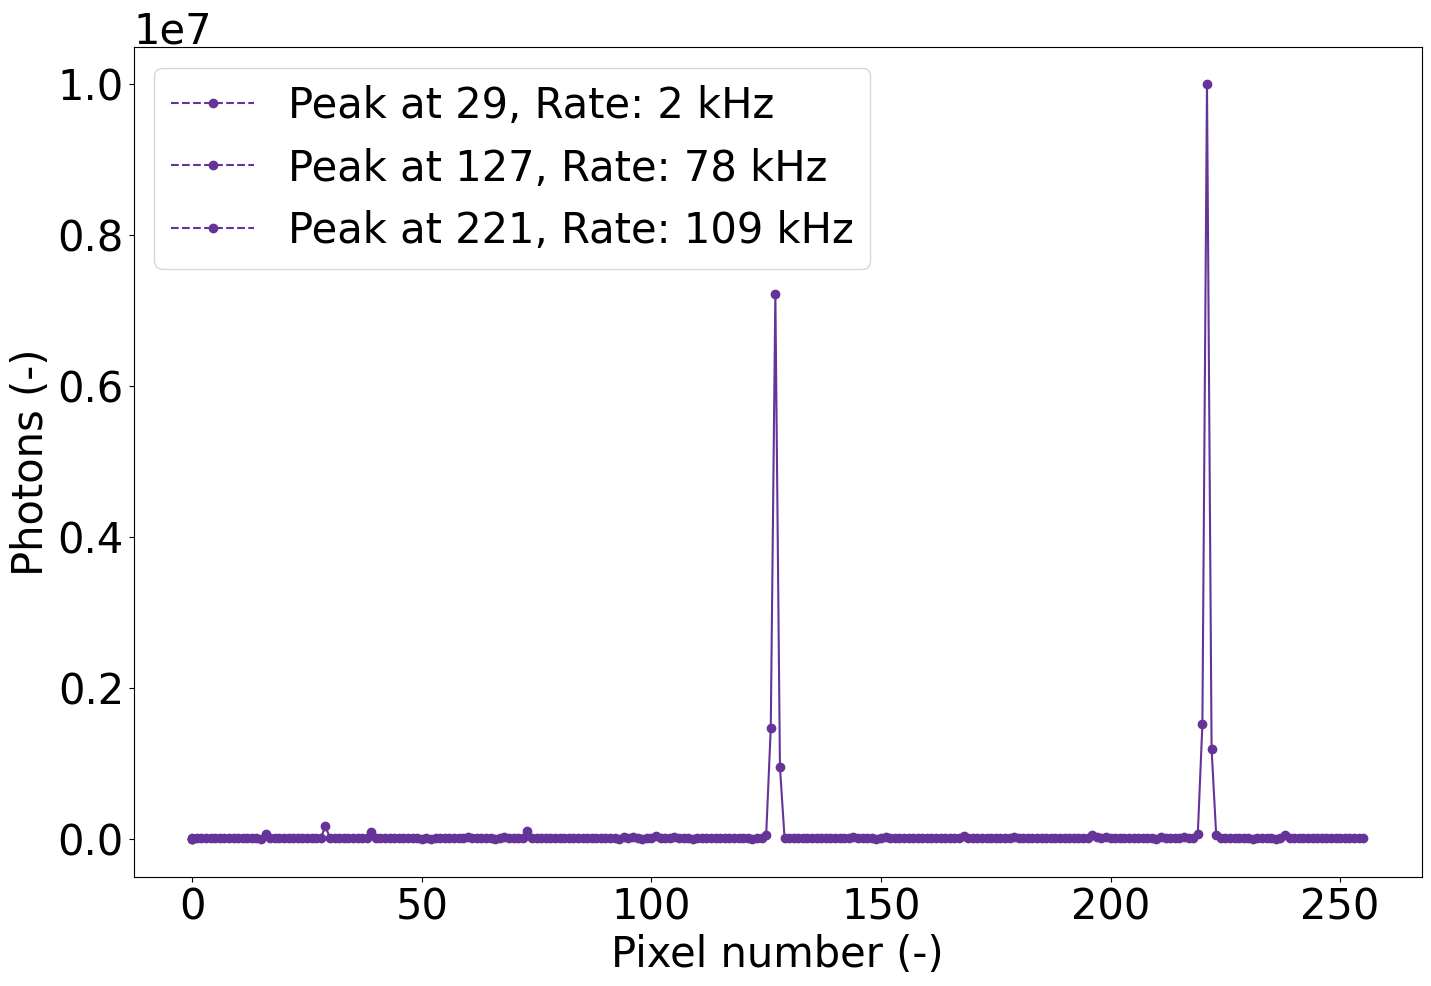

In [20]:
from daplis.functions import sensor_plot, delta_t, fits

path = r"D:\LinoSPAD2\Data\NL11\2025.10.08\23files"

sensor_plot.plot_sensor_population(
    path,
    daughterboard_number="NL11",
    motherboard_number="#33",
    firmware_version="2212b",
    timestamps=800,
)

In [21]:
delta_t.calculate_and_save_timestamp_differences(
    path,
    rewrite=True,
    pixels=[127, 221],
    daughterboard_number="NL11",
    motherboard_number="#33",
    firmware_version="2212b",
    timestamps=800,
    include_offset=True,
)


> > > Collecting data for delta t plot for the requested pixels and saving it to .feather in a cycle < < <




> > > Timestamp differences are saved as0000246030-0000246052.feather in D:\LinoSPAD2\Data\NL11\2025.10.08\23files\delta_ts_data < < <


[[Model]]
    (Model(gaussian) + Model(linear))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 91
    # data points      = 83
    # variables        = 5
    chi-square         = 12251.0601
    reduced chi-square = 157.064874
    Akaike info crit   = 424.545753
    Bayesian info crit = 436.639956
    R-squared          = 0.40158473
[[Variables]]
    amplitude:  14474.8476 +/- 2500.43578 (17.27%) (init = 174857.1)
    center:    -5316.88405 +/- 18.2079038 (0.34%) (init = -5624.369)
    sigma:      95.5646174 +/- 18.4952443 (19.35%) (init = 607.1429)
    fwhm:       225.037472 +/- 43.5529713 (19.35%) == '2.3548200*sigma'
    height:     60.4264334 +/- 10.0218877 (16.59%) == '0.3989423*amplitude/max(1e-15, sigma)'
    slope:     -3.0518e-04 +/- 8.0501e-04 (263.79%) (init = -0.0005401117)
    intercept:  132.576092 +/- 4.28101808 (3.23%) (init = 133.8347)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = +0.9418
    C(amplitude, s

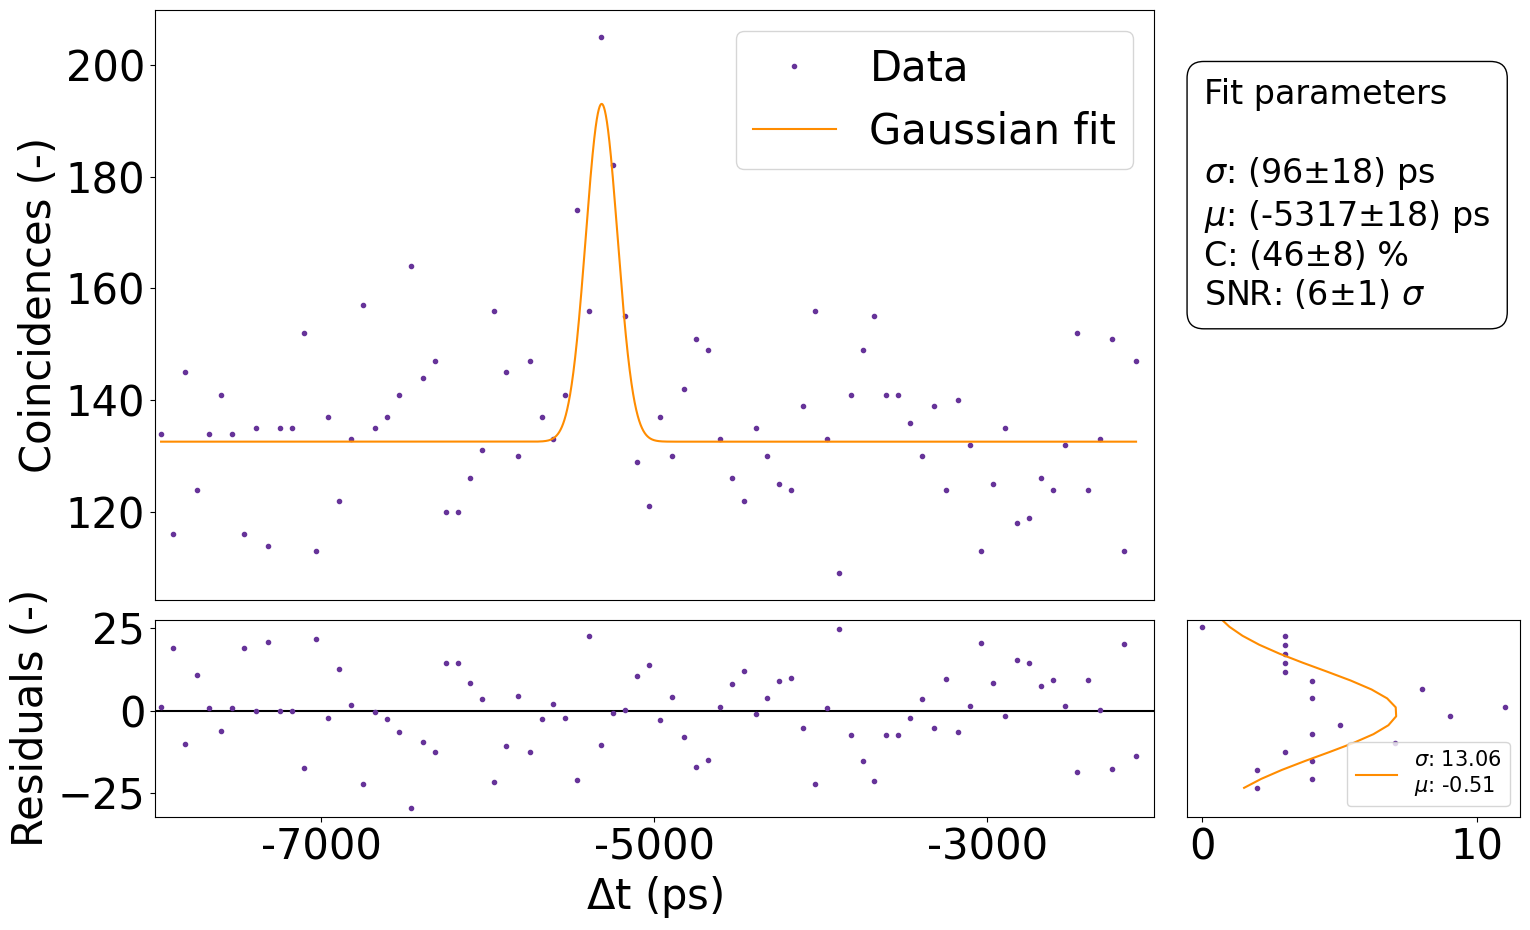

In [22]:
fits.fit_with_gaussian_fancy(
    path, pixels=[127, 221], range_left=-8e3, range_right=-2e3, multiplier=4
)